In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv('../datasets/complex.csv')
df.columns = df.columns.str.strip()  # the CSV has " s1" not "s1"
df = df.set_index('time').dropna()

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    index=df.index,
    columns=df.columns
)

print(df_scaled.shape)
df_scaled.head()

(1008, 3)


,s1,s2,s3
time,,,
0,0.500000,1.000000,0.499999
1,0.505000,0.999975,0.504999
2,0.509999,0.999900,0.509999
3,0.514998,0.999775,0.514997
4,0.519994,0.999600,0.519994


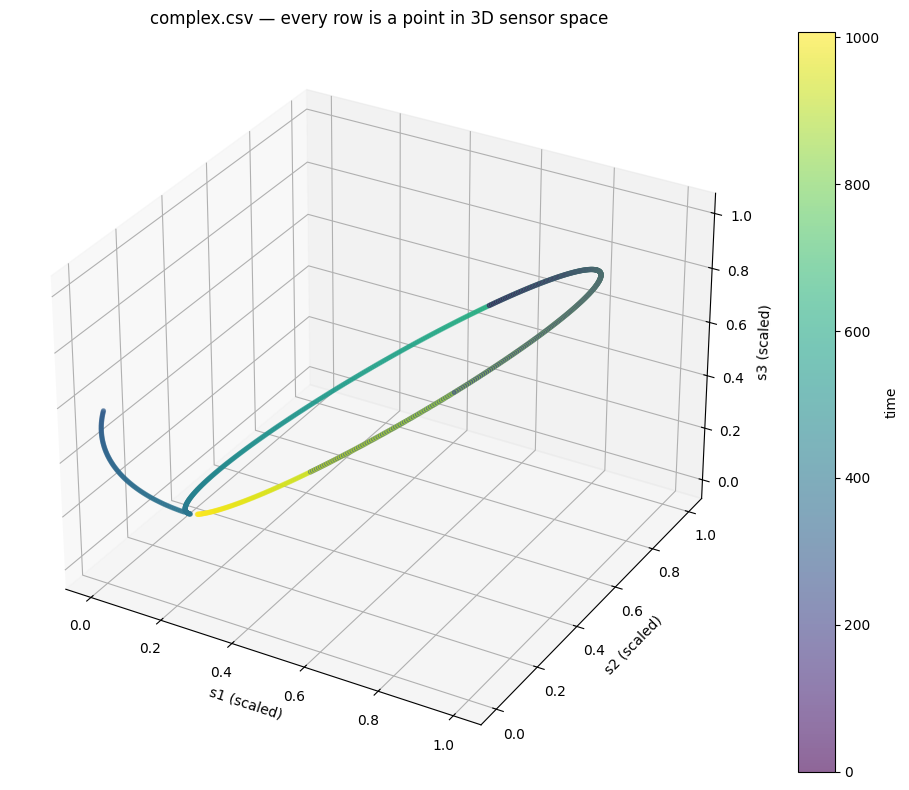

In [4]:
# Cell 2: The 3D cloud — this is literally what OCSVM sees
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colour by time so you can see the trajectory
sc = ax.scatter(
    df_scaled['s1'], df_scaled['s2'], df_scaled['s3'],
    c=df_scaled.index, cmap='viridis', s=8, alpha=0.6
)
ax.set_xlabel('s1 (scaled)')
ax.set_ylabel('s2 (scaled)')
ax.set_zlabel('s3 (scaled)')
ax.set_title('complex.csv — every row is a point in 3D sensor space')
plt.colorbar(sc, label='time')
plt.tight_layout()
plt.show()

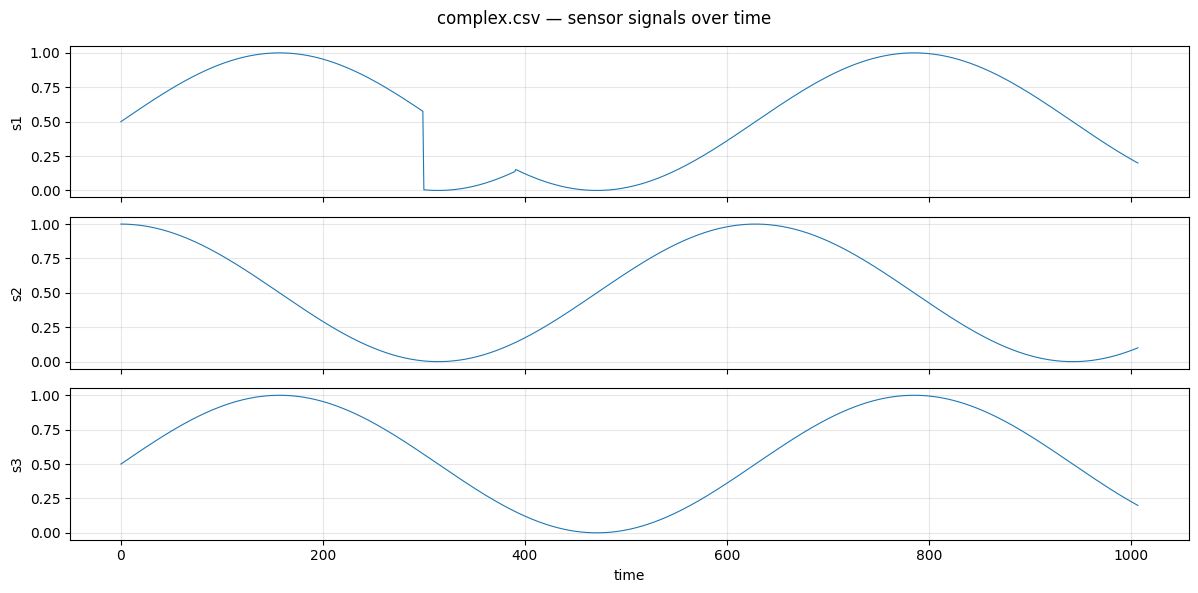

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, col in zip(axes, ['s1', 's2', 's3']):
    ax.plot(df_scaled.index, df_scaled[col], linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('complex.csv — sensor signals over time')
plt.tight_layout()
plt.show()

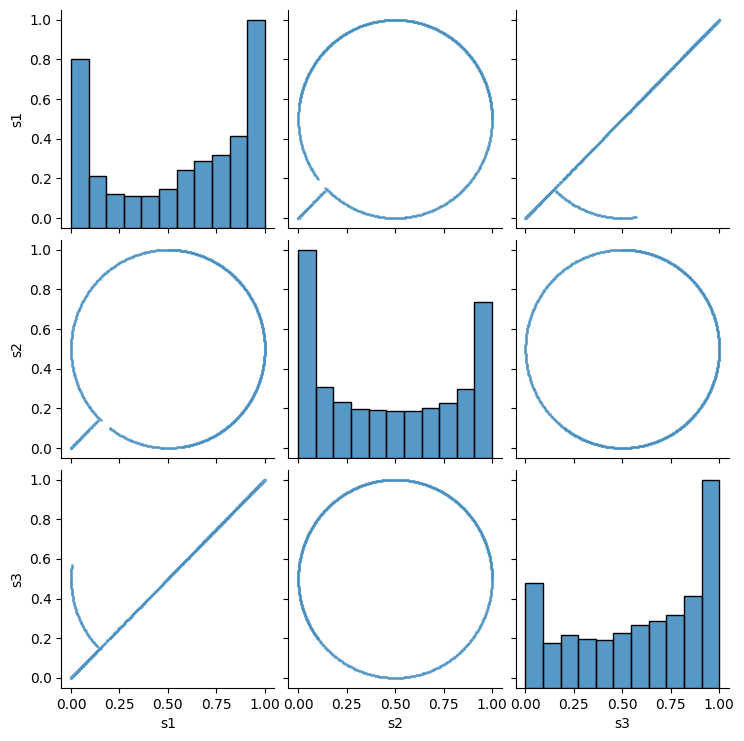

In [9]:
import seaborn as sns
sns.pairplot(df_scaled, plot_kws={'s': 5, 'alpha': 0.5})
plt.show()

# `complex.csv` — exploratory analysis

## What this dataset is

- **Shape**: 1008 rows × 3 sensor columns (`s1`, `s2`, `s3`) + `time` index
- **Origin**: Almost certainly **synthetic** (computer-generated), not real IoT data. The signals are too smooth and mathematically clean to be real sensors. Very likely created by a previous student team for testing purposes.
- **Implication**: Useful for **building and unit-testing the pipeline**, but conclusions drawn from benchmarking on this data won't generalise to real IoT scenarios.

---

## What I see in the plots

### Time-series view (`s1`, `s2`, `s3` over time)

- All three signals are **smooth sinusoids** — clearly generated from `sin()`/`cos()` functions, not measured.
- `s2` and `s3` are **clean sine waves** running across the full timespan.
- `s1` has a **discontinuity around t≈300**: it drops sharply from ~0.6 down to near 0, stays low/erratic until t≈400, then resumes a smooth wave. This looks like a **pre-injected anomaly** — possibly the previous team manually wrote in a "broken sensor" event.
- All signals are normalised to [0, 1] by the MinMax scaler (expected).

### 3D cloud (the view OCSVM actually sees)

- The 1008 points form a **clear closed loop / ribbon** in 3D space — almost a flat ellipse.
- This is the geometric signature of **periodic correlated signals** — when sensors move in coordinated waves, their joint position traces a curve, not a blob.
- The `s1` anomaly window (~t=300–400) shows up as the **small detached arc** sitting away from the main ribbon.
- **Key insight**: most of the 3D space is empty. The "normal" region is a thin curve, not a wide cluster. This is *ideal* for OCSVM — it can draw a tight boundary around the curve and anything off the curve is anomalous.

### Pairplot (s1 vs s2, s1 vs s3, s2 vs s3)

- **`s1` vs `s3`** → a near-perfect **straight diagonal line** with a small detached branch. They are almost identical signals (linearly dependent). One of them is essentially redundant.
- **`s1` vs `s2`** and **`s2` vs `s3`** → both form **circles**. This means `s2` is 90° phase-shifted from `s1`/`s3` (e.g. one is `sin(t)`, the other is `cos(t)`). When you plot a sine vs its cosine, you get a circle.
- **Histograms (diagonal)**: U-shaped — typical of sine waves, which spend most of their time near the peaks (±1) and pass through the middle quickly.
- The small detached branch on `s1`-vs-`s3` is the t=300 anomaly again.

---

## What this means for OCSVM

- The data has **strong multivariate structure** (`s1` ~ `s3`, `s2` is 90° out of phase). OCSVM can learn this geometric pattern and flag anything that breaks it.
- This is exactly the kind of anomaly **per-column detectors (ADTK QuantileAD, etc.) can't catch**: if `s1` momentarily ignores its relationship with `s3`, no individual-sensor detector will flag it — but OCSVM will, because the joint point falls off the ribbon.
- The t=300 anomaly is **already present in the data** and OCSVM should flag it. Useful sanity check for the wrapper.

## Limitations of this dataset for the project

- **No ground-truth labels** for anomalies → can't compute precision/recall directly.
- **Too clean** to be representative of real IoT noise.
- **Tiny** (1008 rows).
- Only **one anomaly event** (the t=300 dip) — not enough variety to benchmark different anomaly *types* (point, contextual, collective, drift, etc.).
- → Need a richer dataset before final evaluation. Synthetic anomaly injection on top of clean data is the team's planned answer; real data from ThingSpeak is the longer-term goal.

Very useful interpretation: ADTK detectors looks at one column at a time, and OCSVM looks at all columns together
OCSVM learns the shape of "normal" by drawing a tight boundary around your training data in multi-dimensional sensor space, then flags anything that lands outside that boundary.